# Tuần 1 — Wine Dataset
Thành Viên 1: Chuyên gia Dữ liệu & Trực quan hóa

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Bước 1: Đọc file và đặt tên cột

In [12]:
df = pd.read_excel('Wine-Classification-DataMining/wine.data.xlsx', sheet_name='wine.data', header=0)
col_names = [
    'Class','Alcohol','Malic_Acid','Ash','Alcalinity_of_Ash',
    'Magnesium','Total_Phenols','Flavanoids','Nonflavanoid_Phenols',
    'Proanthocyanins','Color_Intensity','Hue','OD280_OD315','Proline'
]
df.columns = col_names
df['Class'] = df['Class'].astype(int)
df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Bước 2: Kiểm tra tổng quan dataset

In [13]:
print(f'Kich thuoc: {df.shape[0]} mau x {df.shape[1]} cot')
print('\nKieu du lieu:')
print(df.dtypes)
print('\nSo mau theo nhan:')
print(df['Class'].value_counts().sort_index())

Kich thuoc: 178 mau x 14 cot

Kieu du lieu:
Class                     int64
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Alcalinity_of_Ash       float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280_OD315             float64
Proline                   int64
dtype: object

So mau theo nhan:
Class
1    59
2    71
3    48
Name: count, dtype: int64


## Bước 3: Thống kê Max / Min / Mean

In [14]:
features = col_names[1:]
stats = df[features].agg(['max', 'min', 'mean']).T.round(4)
stats.columns = ['Max', 'Min', 'Mean']
print(stats)

                          Max     Min      Mean
Alcohol                 14.83   11.03   13.0006
Malic_Acid               5.80    0.74    2.3363
Ash                      3.23    1.36    2.3665
Alcalinity_of_Ash       30.00   10.60   19.4949
Magnesium              162.00   70.00   99.7416
Total_Phenols            3.88    0.98    2.2951
Flavanoids               5.08    0.34    2.0293
Nonflavanoid_Phenols     0.66    0.13    0.3619
Proanthocyanins          3.58    0.41    1.5909
Color_Intensity         13.00    1.28    5.0581
Hue                      1.71    0.48    0.9574
OD280_OD315              4.00    1.27    2.6117
Proline               1680.00  278.00  746.8933


## Bước 4: Chuẩn hóa dữ liệu với StandardScaler

In [15]:
scaler = StandardScaler()
X = df[features].values
X_scaled = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.insert(0, 'Class', df['Class'].values)
df_scaled.to_csv('wine_scaled.csv', index=False)
print('Da luu: scaler.pkl')
print('Da luu: wine_scaled.csv')

Da luu: scaler.pkl
Da luu: wine_scaled.csv


## Bước 5: PCA 2D và Scatter Plot

PC1: 36.2%  PC2: 19.2%  Tong: 55.4%


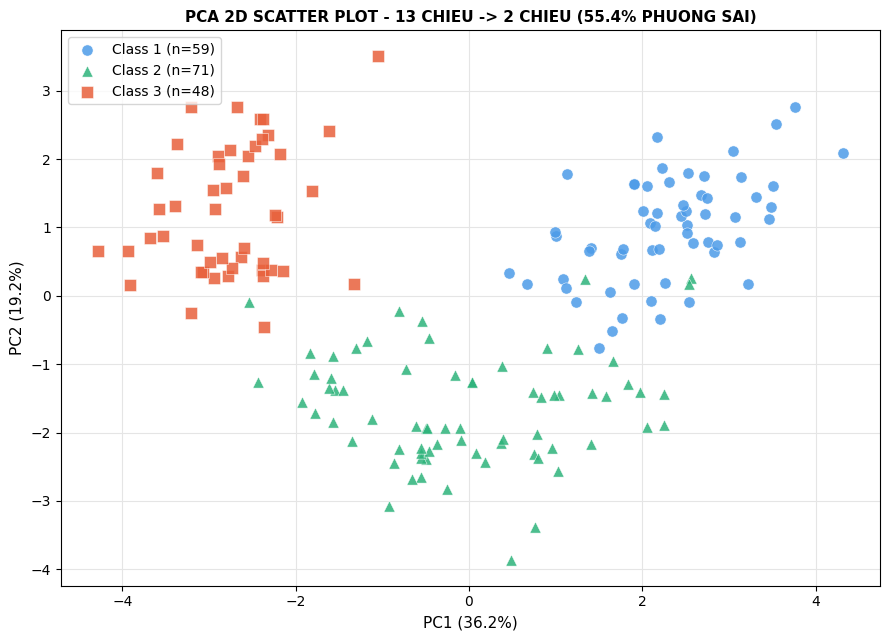

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print(f'PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%  Tong: {sum(ev)*100:.1f}%')
colors  = {1: '#4C9BE8', 2: '#2DB37A', 3: '#E8613C'}
markers = {1: 'o', 2: '^', 3: 's'}
labels  = df['Class'].values
counts  = df['Class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for cls in [1, 2, 3]:
    mask = labels == cls
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cls], marker=markers[cls],
               label=f'Class {cls} (n={counts[cls]})', alpha=0.85,
               edgecolors='white', linewidths=0.4, s=65, zorder=3)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=11)
ax.set_title(f'PCA 2D SCATTER PLOT - 13 CHIEU -> 2 CHIEU ({sum(ev)*100:.1f}% PHUONG SAI)', fontsize=11, fontweight='bold')
ax.grid(True, color='#e5e5e5', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=True, fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Tuần 2 — Wine Dataset

## Bước 1: Khung 10-Fold
* **Mục tiêu:** Tạo bộ chia dữ liệu 10-Fold Cross-Validation đồng nhất cho tất cả các mô hình.
* **Kỹ thuật:** Sử dụng `StratifiedKFold` với `random_state=42` để duy trì tỷ lệ lớp gốc và đảm bảo kết quả tái lập được giữa các thành viên.
* **Độ đo:** `Weighted F1-Score` xử lý dữ liệu mất cân bằng.

In [21]:
# KHUNG KIỂM ĐỊNH CHÉO DÙNG CHUNG CỦA TUẦN 2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

print("--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---")

# Thống nhất khung kiểm định 10-Fold để tất cả các mô hình dùng chung
cv_folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Thống nhất độ đo Weighted F1-Score
weighted_f1_scorer = make_scorer(f1_score, average='weighted')

print("-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.")

--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---
-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.


## Bước 3: Huấn luyện và tinh chỉnh tham số cho mô hình Naive Bayes
* **Mục tiêu:** Tinh chỉnh hệ số làm mịn `var_smoothing` bằng `GridSearchCV`.
* **Kế thừa:** Sử dụng lại dữ liệu chuẩn hóa từ Tuần 1 và khung đánh giá từ Bước 1.

--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---

[Đang chạy] Quét 100 giá trị tham số trên 10-Fold CV...
-------------------------------------------------------
KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:
-> Tham số var_smoothing tốt nhất: 1.87e-01
-> Weighted F1-Score cao nhất đạt được: 0.9834
-------------------------------------------------------


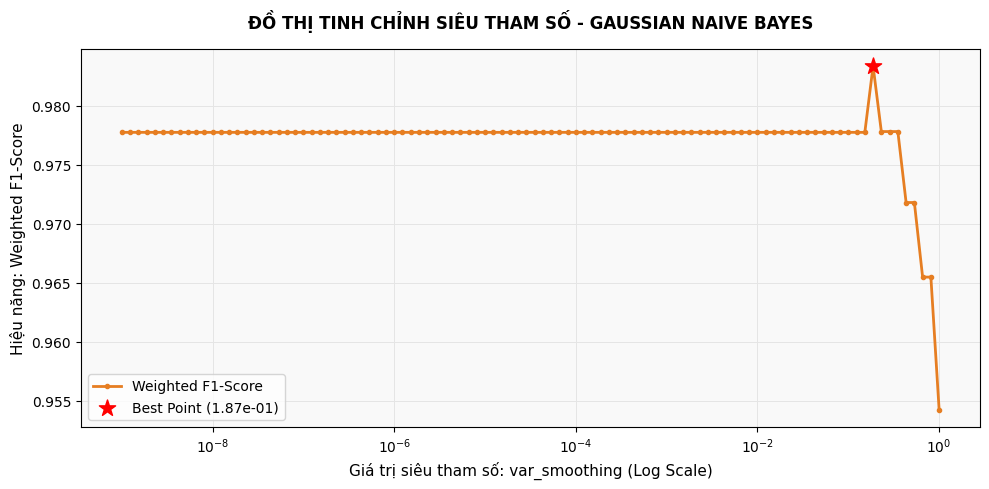

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt

print("--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---\n")

# 1. Kế thừa dữ liệu từ Thành viên 1
X_input = X_scaled
y_input = labels

# 2. Khởi tạo mô hình và không gian lưới 100 bước
nb_model = GaussianNB()
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Kích hoạt GridSearchCV (Tự động kế thừa biến 'cv_folds' và 'weighted_f1_scorer' ở ô trên)
print("[Đang chạy] Quét 100 giá trị tham số trên 10-Fold CV...")
grid_search_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid_nb,
    cv=cv_folds,
    scoring=weighted_f1_scorer,
    n_jobs=-1
)
grid_search_nb.fit(X_input, y_input)

# 4. Trích xuất kết quả tối ưu
best_nb_params = grid_search_nb.best_params_
best_nb_f1 = grid_search_nb.best_score_

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:")
print(f"-> Tham số var_smoothing tốt nhất: {best_nb_params['var_smoothing']:.2e}")
print(f"-> Weighted F1-Score cao nhất đạt được: {best_nb_f1:.4f}")
print("-" * 55)

# 5. Vẽ đồ thị Validation Curve
cv_results = grid_search_nb.cv_results_
param_values = param_grid_nb['var_smoothing']
mean_scores = cv_results['mean_test_score']

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

plt.plot(param_values, mean_scores, color='#e67e22', marker='o', markersize=3,
         linestyle='-', linewidth=2, label='Weighted F1-Score')

plt.scatter(best_nb_params['var_smoothing'], best_nb_f1, color='red', marker='*',
            s=150, zorder=5, label=f"Best Point ({best_nb_params['var_smoothing']:.2e})")

plt.xscale('log')
plt.xlabel('Giá trị siêu tham số: var_smoothing (Log Scale)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ - GAUSSIAN NAIVE BAYES', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, which="both", color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('naive_bayes_tuning.png', dpi=150)
plt.show()